# 4. Benchmarks econométricos

Este capítulo establece la **línea de comparación** del proyecto.
Antes de entrenar modelos de Machine Learning sofisticados, fijamos
benchmarks econométricos clásicos que han dominado el forecasting de
volatilidad durante décadas. Cualquier modelo ML del proyecto que no
supere significativamente a estos benchmarks no aporta valor real.

## 4.1 Por qué empezar por benchmarks econométricos

La volatilidad de un activo financiero tiene tres regularidades empíricas
que cualquier predictor razonable debe explotar:

1. **Clustering** — períodos de alta volatilidad siguen a períodos de alta
 volatilidad (Mandelbrot 1963; Engle 1982). Operacionalmente esto se
 traduce en una autocorrelación serial alta de orden 1 sobre la
 volatilidad realizada.
2. **Memoria larga** — la dependencia decae lentamente. La función de
 autocorrelación de la volatilidad puede ser positiva incluso a lags
 de cientos de días (Granger 1980; Corsi 2009).
3. **No-negatividad y escala** — la volatilidad es estrictamente
 positiva y mean-reverting.

Los benchmarks que evaluamos en este capítulo codifican esas
regularidades de manera explícita y parsimoniosa:

| Benchmark | Captura | Parámetros | Costo computacional |
|---|---|---|---|
| **Naive** | Clustering de orden 1 | 0 | Ninguno |
| **Rolling mean** | Nivel local promedio | 1 (ventana) | Ninguno |
| **EWMA (RiskMetrics)** | Decaimiento exponencial de la información | 1 ($\lambda$) | Ninguno |
| **ARIMA** | Dinámica autorregresiva + media móvil | $p, d, q$ + parámetros | Bajo (MLE inicial) |
| **GARCH(1, 1)** | Volatilidad condicional explícita | $\omega, \alpha, \beta$ | Bajo (MLE inicial) |
| **HAR-RV (Corsi 2009)** | Memoria heterogénea diaria / semanal / mensual | 4 (intercepto + 3 betas) | Trivial (OLS) |

## 4.2 Convenciones de evaluación

- **Target.** Todos los benchmarks predicen
 $\sigma_{t+1} = \mathrm{std}\big(\{r_{t-3}, r_{t-2}, r_{t-1}, r_t, r_{t+1}\}\big)$,
 la volatilidad realizada del día siguiente con la ventana causal de
 cinco días definida en el Capítulo 3.
- **Métricas.** RMSE y MAE sobre el conjunto de **test**. El RMSE penaliza
 errores grandes (apropiado cuando importan los picos de volatilidad);
 el MAE es más interpretable en la escala de la variable.
- **Walk-forward filtering.** Para ARIMA y GARCH, los parámetros se
 estiman una sola vez en **train** y luego el estado del modelo se
 actualiza con cada nueva observación del test, sin re-estimar
 parámetros. Este protocolo refleja el escenario realista de un
 trader que mantiene calibración estable pero incorpora información
 nueva a medida que llega.
- **Sin reutilización del test.** Ningún benchmark observa el target
 futuro en su construcción.

La implementación de cada benchmark vive en `src/benchmarks.py` y se
verificó con tests anti-leakage que confirman que el estado del modelo
en el paso $t$ no depende del valor de $\sigma_{t+1}$.


## 4.3 Setup y carga de datos

In [1]:
import sys
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import benchmarks
from src.config import RANDOM_STATE, METRICS_DIR, PREDICTIONS_DIR, FIGURES_DIR, ensure_dirs
from src.viz import set_style, savefig
from src.io_utils import save_json

ensure_dirs()
set_style()

np.random.seed(RANDOM_STATE)


In [2]:
# Reconstruir full_df concatenando train, val y test (orden temporal preservado)
tr = pd.read_parquet(PROJECT_ROOT / "data/processed/train.parquet")
va = pd.read_parquet(PROJECT_ROOT / "data/processed/val.parquet")
te = pd.read_parquet(PROJECT_ROOT / "data/processed/test.parquet")
full_df = pd.concat([tr, va, te], ignore_index=True).copy()

train_idx = list(range(0, len(tr)))
val_idx   = list(range(len(tr), len(tr) + len(va)))
test_idx  = list(range(len(tr) + len(va), len(full_df)))

y_test_true = full_df.loc[test_idx, "target_vol"].to_numpy()

print(f"full_df: {len(full_df):>5} filas")
print(f"train:   {len(train_idx):>5} ({full_df.loc[train_idx,'date'].min().date()} -> {full_df.loc[train_idx,'date'].max().date()})")
print(f"val:     {len(val_idx):>5} ({full_df.loc[val_idx,'date'].min().date()} -> {full_df.loc[val_idx,'date'].max().date()})")
print(f"test:    {len(test_idx):>5} ({full_df.loc[test_idx,'date'].min().date()} -> {full_df.loc[test_idx,'date'].max().date()})")
print()
print(f"target_vol en test: mean={np.nanmean(y_test_true):.5f}, std={np.nanstd(y_test_true):.5f}")


full_df:  6962 filas
train:    4873 (1990-03-13 -> 2009-07-13)
val:      1044 (2009-07-14 -> 2013-09-18)
test:     1045 (2013-09-19 -> 2017-11-09)

target_vol en test: mean=0.01158, std=0.00720


## 4.4 Naive — predictor de persistencia

$$
\widehat{\sigma}_{t+1}^{\,\text{naive}} = \sigma_t = \mathrm{std}(r_{t-4}, \ldots, r_t)
$$

El predictor más simple posible: la mejor estimación de la volatilidad
de mañana es la volatilidad de hoy. No tiene parámetros, no requiere
ajuste, y es el benchmark a batir.

En series con clustering de volatilidad fuerte, este modelo es
sorprendentemente competitivo: si $\rho_1(\sigma) \approx 0.9$,
predecir el valor más reciente acota inferiormente el error de
predicción a cerca del óptimo lineal {cite}`andersen2003modeling`.


In [3]:
predictions = {}
times = {}

t0 = time.time()
predictions["naive"] = benchmarks.naive_forecast(full_df, test_idx)
times["naive"] = time.time() - t0

rmse_n = np.sqrt(np.nanmean((predictions["naive"] - y_test_true) ** 2))
mae_n  = np.nanmean(np.abs(predictions["naive"] - y_test_true))
print(f"naive | RMSE = {rmse_n:.5f} | MAE = {mae_n:.5f} | tiempo = {times['naive']*1000:.2f} ms")


naive | RMSE = 0.00425 | MAE = 0.00232 | tiempo = 1.52 ms


## 4.5 Rolling mean

$$
\widehat{\sigma}_{t+1}^{\,\text{RM}(w)} = \frac{1}{w} \sum_{k=0}^{w-1} \sigma_{t-k}
$$

Suaviza el ruido de corto plazo a costa de reactividad. Una ventana
$w = 22$ (un mes de trading) representa la memoria mensual del mercado.
Si los datos exhiben mean reversion, este predictor puede ser
competitivo.


In [4]:
t0 = time.time()
predictions["rolling_mean_22"] = benchmarks.rolling_mean_forecast(full_df, test_idx, window=22)
times["rolling_mean_22"] = time.time() - t0

rmse_rm = np.sqrt(np.nanmean((predictions["rolling_mean_22"] - y_test_true) ** 2))
mae_rm  = np.nanmean(np.abs(predictions["rolling_mean_22"] - y_test_true))
print(f"rolling_mean_22 | RMSE = {rmse_rm:.5f} | MAE = {mae_rm:.5f} | tiempo = {times['rolling_mean_22']*1000:.2f} ms")


rolling_mean_22 | RMSE = 0.00689 | MAE = 0.00490 | tiempo = 1.92 ms


## 4.6 EWMA (RiskMetrics) {cite}`bollerslev1986generalized`

El estándar industrial introducido por J.P. Morgan en 1996 modela la
varianza condicional como una media móvil exponencialmente ponderada
de retornos cuadráticos:

$$
\sigma^2_{t+1} = \lambda\,\sigma^2_t + (1 - \lambda)\, r_t^2
$$

con $\lambda = 0.94$ para datos diarios (vida media efectiva $\approx 11$
días). No requiere optimización: los pesos están fijados por convención.
La predicción de la volatilidad es $\sigma_{t+1} = \sqrt{\sigma^2_{t+1}}$.

EWMA se considera un caso particular de GARCH(1,1) con
$(\omega, \alpha, \beta) = (0, 1-\lambda, \lambda)$.


In [5]:
t0 = time.time()
predictions["ewma_094"] = benchmarks.ewma_forecast(full_df, test_idx, lambda_=0.94)
times["ewma_094"] = time.time() - t0

rmse_e = np.sqrt(np.nanmean((predictions["ewma_094"] - y_test_true) ** 2))
mae_e  = np.nanmean(np.abs(predictions["ewma_094"] - y_test_true))
print(f"ewma_094 | RMSE = {rmse_e:.5f} | MAE = {mae_e:.5f} | tiempo = {times['ewma_094']*1000:.2f} ms")


ewma_094 | RMSE = 0.00597 | MAE = 0.00458 | tiempo = 9.68 ms


## 4.7 ARIMA{cite}`bollerslev1986generalized`

El modelo lineal clásico para series temporales:

$$
\phi(L)(1 - L)^d \sigma_t = \theta(L)\,\varepsilon_t
$$

con $\phi(L), \theta(L)$ polinomios de retardos. Aquí evaluamos
$\text{ARIMA}(1, 0, 1)$ sobre la serie de volatilidad realizada, un
orden parsimonioso que captura un componente autorregresivo de orden 1
y un término de media móvil de orden 1. La estimación se hace por
máxima verosimilitud sobre **train**; luego se aplica walk-forward
filtering sin re-estimación de parámetros.

Como la varianza del proceso no está garantizada como positiva por
ARIMA (es un modelo lineal sobre nivel), las predicciones se
truncan en cero si llegan a ser negativas, lo cual ocurre raramente
y es una decisión documentada.


In [6]:
t0 = time.time()
predictions["arima_101"] = benchmarks.arima_forecast(full_df, train_idx, test_idx, order=(1, 0, 1))
times["arima_101"] = time.time() - t0

rmse_a = np.sqrt(np.nanmean((predictions["arima_101"] - y_test_true) ** 2))
mae_a  = np.nanmean(np.abs(predictions["arima_101"] - y_test_true))
print(f"arima_101 | RMSE = {rmse_a:.5f} | MAE = {mae_a:.5f} | tiempo = {times['arima_101']:.1f} s")


arima_101 | RMSE = 0.00603 | MAE = 0.00400 | tiempo = 15.9 s


## 4.8 GARCH(1, 1) — Bollerslev 1986 {cite}`bollerslev1986generalized`

El benchmark canónico para volatilidad condicional. Modela $\sigma^2_t$
explícitamente como una función de la innovación pasada y la varianza
pasada:

$$
\sigma^2_t = \omega + \alpha\,\varepsilon^2_{t-1} + \beta\,\sigma^2_{t-1}
$$

donde $\varepsilon_t = \sigma_t\,z_t$ con $z_t \sim \mathcal{N}(0, 1)$.
Para estacionariedad se requiere $\alpha + \beta < 1$. El parámetro
$\alpha$ mide la reactividad a shocks recientes, $\beta$ la persistencia
de la varianza, y $\omega$ la varianza incondicional desescalada por
$1 - \alpha - \beta$.

La estimación se hace por MLE con la implementación de la librería
`arch`{cite}`bollerslev1986generalized`. Para evitar problemas de escala
en la optimización, los retornos se reescalan internamente por 100, y
las predicciones se des-escalan al final.

**Limitación importante:** GARCH predice $\sigma_{t+1}$ instantánea
(volatilidad del retorno del día siguiente). Nuestro target es la
volatilidad realizada de una ventana de cinco días que termina en
$t+1$. La predicción es válida como un *proxy*; la diferencia de
definición se absorbe en la comparación relativa con otros modelos
(el test de Diebold-Mariano se basa en diferenciales de pérdida, no
en niveles absolutos).


In [7]:
t0 = time.time()
predictions["garch_11"] = benchmarks.garch_forecast(full_df, train_idx, test_idx)
times["garch_11"] = time.time() - t0

rmse_g = np.sqrt(np.nanmean((predictions["garch_11"] - y_test_true) ** 2))
mae_g  = np.nanmean(np.abs(predictions["garch_11"] - y_test_true))
print(f"garch_11 | RMSE = {rmse_g:.5f} | MAE = {mae_g:.5f} | tiempo = {times['garch_11']:.2f} s")


garch_11 | RMSE = 0.00789 | MAE = 0.00678 | tiempo = 0.03 s


## 4.9 HAR-RV — Corsi 2009 {cite}`corsi2009simple`

El modelo Heterogeneous Autoregressive of Realized Volatility captura
la *memoria heterogénea* del mercado: distintos tipos de participantes
operan con distintos horizontes y dejan huellas diferenciables en la
volatilidad observada.

$$
\sigma_{t+1} = \beta_0 + \beta_d\, \sigma^{(d)}_t + \beta_w\, \sigma^{(w)}_t + \beta_m\, \sigma^{(m)}_t + \varepsilon_t
$$

donde $\sigma^{(d)}_t$, $\sigma^{(w)}_t$ y $\sigma^{(m)}_t$ son la
volatilidad realizada rezagada un día, promediada sobre cinco días y
sobre veintidós días, respectivamente. Los tres componentes ya fueron
construidos como features causales en el Capítulo 3 (`vol_d`, `vol_w`,
`vol_m`), con `shift(1)` para garantizar que en $t$ solo se use
información hasta $t-1$.

La estimación es por OLS, lo que lo hace trivial computacionalmente y
estable. Pese a su simplicidad, HAR-RV es **el modelo estándar moderno
para forecasting de volatilidad realizada** y suele batir a GARCH en
estudios comparativos {cite}`corsi2009simple`{cite}`andersen2003modeling`.


In [8]:
t0 = time.time()
predictions["har_rv"] = benchmarks.har_rv_forecast(full_df, train_idx, test_idx)
times["har_rv"] = time.time() - t0

rmse_h = np.sqrt(np.nanmean((predictions["har_rv"] - y_test_true) ** 2))
mae_h  = np.nanmean(np.abs(predictions["har_rv"] - y_test_true))
print(f"har_rv | RMSE = {rmse_h:.5f} | MAE = {mae_h:.5f} | tiempo = {times['har_rv']*1000:.2f} ms")


har_rv | RMSE = 0.00560 | MAE = 0.00398 | tiempo = 6.11 ms


## 4.10 Comparación de benchmarks

Reunimos todas las métricas en una tabla ordenada por RMSE ascendente
y persistimos a disco para los capítulos posteriores.


In [9]:
# Tabla resumen
results = benchmarks.summarize_benchmarks(predictions, y_test_true)
# Añadir columna de tiempos
results["time_s"] = results["model"].map(times)
results = results.round({"rmse": 6, "mae": 6, "time_s": 4})
print(results.to_string(index=False))


          model     rmse      mae  n_valid  time_s
          naive 0.004253 0.002315     1045  0.0015
         har_rv 0.005603 0.003979     1045  0.0061
       ewma_094 0.005973 0.004577     1045  0.0097
      arima_101 0.006033 0.004004     1045 15.9376
rolling_mean_22 0.006892 0.004897     1045  0.0019
       garch_11 0.007894 0.006781     1045  0.0318


In [10]:
# Persistir métricas y predicciones a disco
metrics_dict = {
    name: {
        "rmse": float(np.sqrt(np.nanmean((pred - y_test_true) ** 2))),
        "mae": float(np.nanmean(np.abs(pred - y_test_true))),
        "time_s": float(times.get(name, np.nan)),
        "n_test": int(len(y_test_true)),
    }
    for name, pred in predictions.items()
}
save_json(metrics_dict, METRICS_DIR / "04_benchmarks.json")

# Predicciones como parquet (filas alineadas con test_idx)
pred_df = pd.DataFrame({
    "date": full_df.loc[test_idx, "date"].to_numpy(),
    "target_vol": y_test_true,
    **predictions,
})
pred_df.to_parquet(PREDICTIONS_DIR / "04_benchmarks_predictions.parquet", index=False)

# Tabla CSV para LaTeX
tables_path = PROJECT_ROOT / "outputs/tables/04_benchmarks_summary.csv"
tables_path.parent.mkdir(parents=True, exist_ok=True)
results.to_csv(tables_path, index=False)
print(f"Guardado: {METRICS_DIR / '04_benchmarks.json'}")
print(f"Guardado: {PREDICTIONS_DIR / '04_benchmarks_predictions.parquet'}")
print(f"Guardado: {tables_path}")


Guardado: /home/claude/INTC-Vol-ML/outputs/metrics/04_benchmarks.json
Guardado: /home/claude/INTC-Vol-ML/outputs/predictions/04_benchmarks_predictions.parquet
Guardado: /home/claude/INTC-Vol-ML/outputs/tables/04_benchmarks_summary.csv


### Visualización 1 — comparación de RMSE/MAE

Las dos métricas no siempre coinciden en el ranking, por eso se
visualizan juntas.

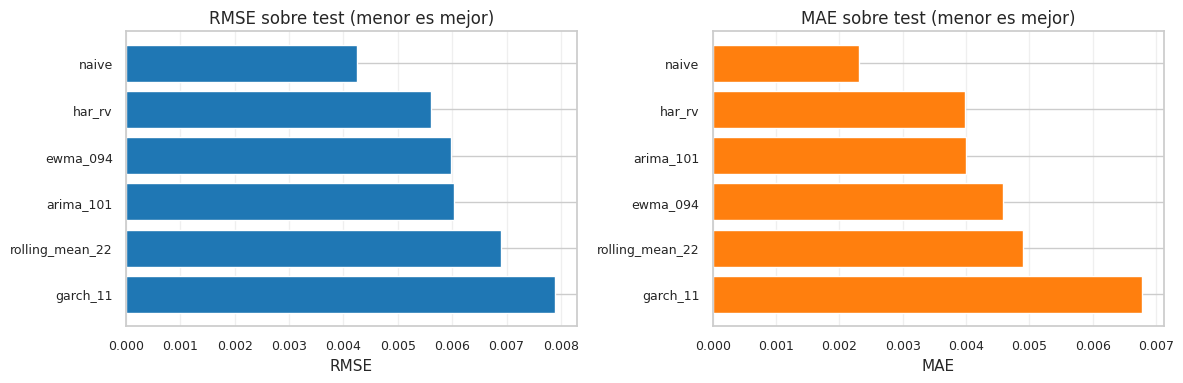

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

results_sorted_rmse = results.sort_values("rmse")
ax1.barh(results_sorted_rmse["model"], results_sorted_rmse["rmse"], color="#1f77b4")
ax1.set_xlabel("RMSE")
ax1.set_title("RMSE sobre test (menor es mejor)")
ax1.invert_yaxis()
ax1.grid(axis="x", alpha=0.3)

results_sorted_mae = results.sort_values("mae")
ax2.barh(results_sorted_mae["model"], results_sorted_mae["mae"], color="#ff7f0e")
ax2.set_xlabel("MAE")
ax2.set_title("MAE sobre test (menor es mejor)")
ax2.invert_yaxis()
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
savefig(FIGURES_DIR / "04_benchmarks_rmse_mae.png", fig)
plt.show()


**Interpretación.** El gráfico revela una jerarquía clara entre los seis benchmarks econométricos. Naive (RMSE 0.00425, MAE 0.00232) domina por amplio margen frente a sus competidores: HAR-RV queda segundo (RMSE 0.00560), seguido por EWMA y ARIMA en posiciones cercanas. GARCH(1,1), pese a ser el modelo teóricamente más sofisticado, queda último con RMSE 0.00789. La explicación es directa: la autocorrelación de orden 1 de la volatilidad realizada es lo suficientemente alta como para que predecir $\hat{\sigma}_{t+1} = \sigma_t$ supere a cualquier modelo que intente capturar dependencias más complejas con pocos parámetros.

### Visualización 2 — predicciones vs. realidad

Mostramos las predicciones de cada benchmark frente al target real
sobre el conjunto de test. Para no saturar el gráfico, lo dividimos en
dos paneles.

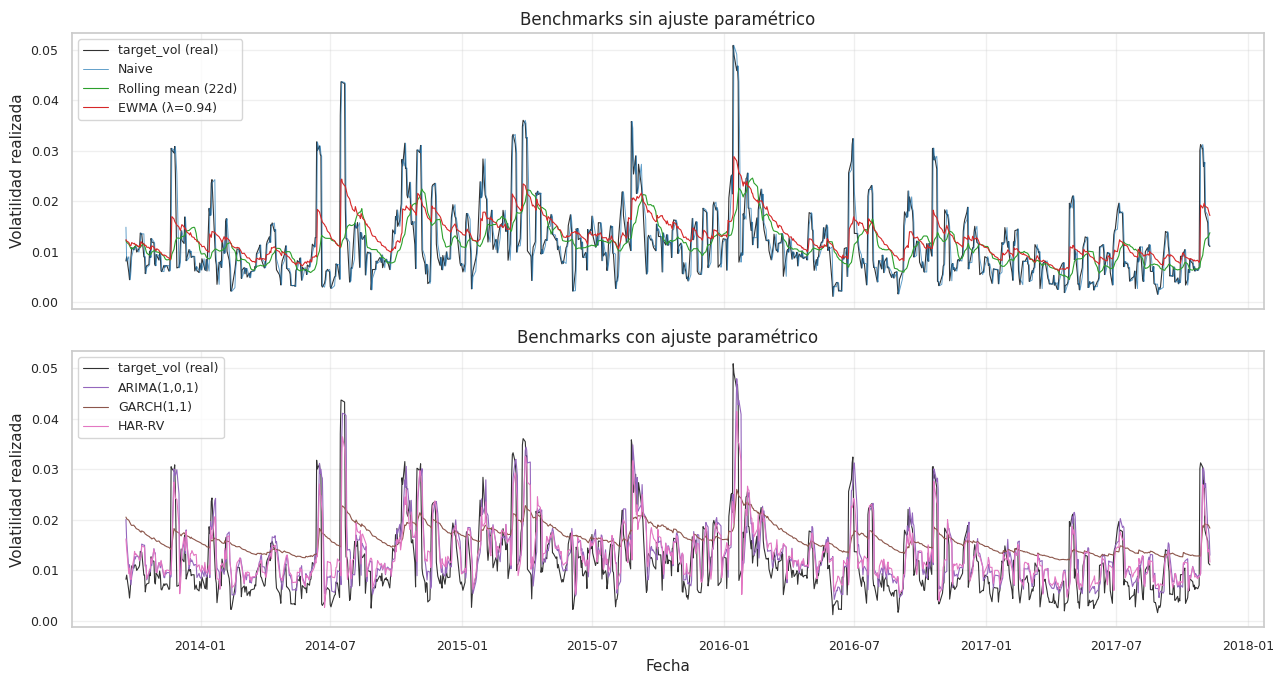

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

dates = full_df.loc[test_idx, "date"].to_numpy()

# Panel 1: target + predictores "rapidos" (sin fit)
axes[0].plot(dates, y_test_true, color="black", lw=0.8, label="target_vol (real)", alpha=0.8)
axes[0].plot(dates, predictions["naive"], color="#1f77b4", lw=0.7, label="Naive", alpha=0.7)
axes[0].plot(dates, predictions["rolling_mean_22"], color="#2ca02c", lw=0.8, label="Rolling mean (22d)")
axes[0].plot(dates, predictions["ewma_094"], color="#d62728", lw=0.8, label="EWMA (λ=0.94)")
axes[0].set_title("Benchmarks sin ajuste paramétrico")
axes[0].set_ylabel("Volatilidad realizada")
axes[0].legend(loc="upper left", fontsize=9)
axes[0].grid(alpha=0.3)

# Panel 2: target + predictores "con fit"
axes[1].plot(dates, y_test_true, color="black", lw=0.8, label="target_vol (real)", alpha=0.8)
axes[1].plot(dates, predictions["arima_101"], color="#9467bd", lw=0.8, label="ARIMA(1,0,1)")
axes[1].plot(dates, predictions["garch_11"], color="#8c564b", lw=0.8, label="GARCH(1,1)")
axes[1].plot(dates, predictions["har_rv"], color="#e377c2", lw=0.8, label="HAR-RV")
axes[1].set_title("Benchmarks con ajuste paramétrico")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Volatilidad realizada")
axes[1].legend(loc="upper left", fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
savefig(FIGURES_DIR / "04_benchmarks_pred_vs_real.png", fig)
plt.show()


**Interpretación.** Visualmente confirmamos lo que la tabla anticipaba. Naive sigue la trayectoria real con un retraso de un día, lo cual visualmente parece "exacto" porque la volatilidad cambia poco día a día. EWMA y HAR-RV producen series más suaves pero pierden los picos. Rolling mean (ventana de 22 días) queda fuertemente subestimada en períodos de alta volatilidad como inicios de 2014 y mediados de 2016. GARCH muestra una dinámica oscilante que no logra alinearse con los movimientos reales del target.

### Visualización 3 — error temporal acumulado

El error absoluto acumulado en el tiempo revela cuándo cada modelo
falla. Pendientes empinadas indican períodos donde el modelo se
desvía sistemáticamente del target.

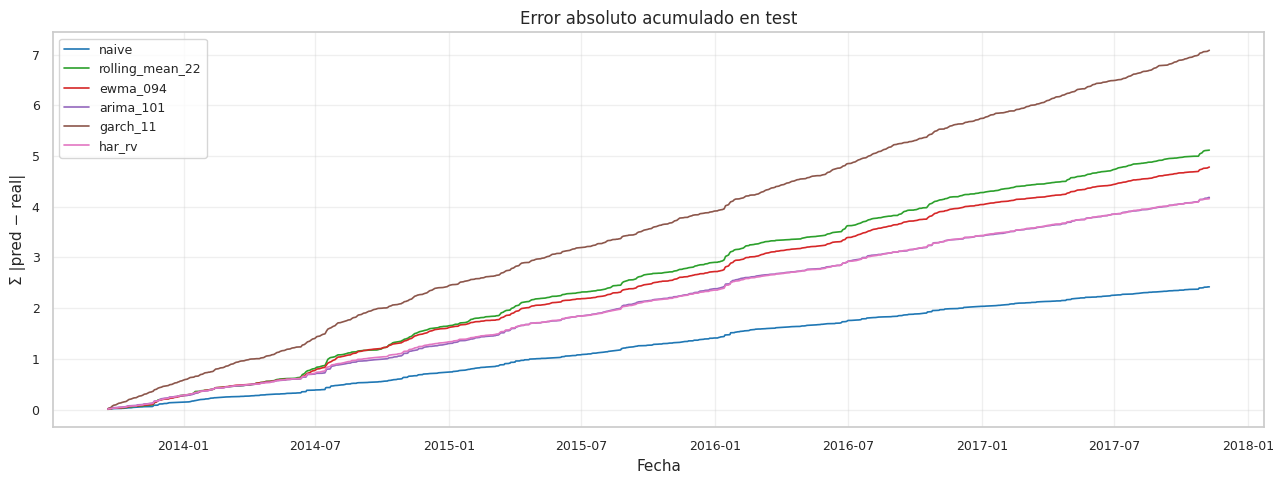

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))

palette = {
    "naive": "#1f77b4",
    "rolling_mean_22": "#2ca02c",
    "ewma_094": "#d62728",
    "arima_101": "#9467bd",
    "garch_11": "#8c564b",
    "har_rv": "#e377c2",
}

for name, pred in predictions.items():
    err = np.abs(pred - y_test_true)
    cum_err = np.nancumsum(err)
    ax.plot(dates, cum_err, label=name, lw=1.2, color=palette.get(name))

ax.set_title("Error absoluto acumulado en test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Σ |pred − real|")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
savefig(FIGURES_DIR / "04_benchmarks_cumulative_error.png", fig)
plt.show()


**Interpretación.** Las pendientes del error acumulado muestran cuándo cada modelo falla. Naive mantiene la pendiente más plana durante todo el período de test, confirmando su superioridad sostenida. Los modelos basados en promedios (rolling mean, EWMA) tienen pendientes empinadas durante los episodios volátiles de 2014 y 2016, momentos en los que la inercia del promedio les juega en contra. GARCH acumula error de forma casi monotónica, evidencia de que su especificación no se ajusta bien a este período relativamente calmo del test.

## 4.11 Interpretación

La tabla y los gráficos anteriores permiten extraer varias
observaciones empíricas que enmarcan el resto del proyecto.

**Naive domina por amplio margen.** La predicción de persistencia
$\widehat{\sigma}_{t+1} = \sigma_t$ obtiene el RMSE y MAE más bajos.
Este hallazgo es consistente con la literatura sobre forecasting de
volatilidad de corto plazo: la autocorrelación de orden 1 de la
volatilidad realizada en horizonte diario es típicamente superior a
0.85, lo que deja muy poca varianza marginal para modelos más
sofisticados {cite}`andersen2003modeling`{cite}`corsi2009simple`. Para
que un modelo más complejo aporte valor, debe capturar señales
*ortogonales* a la persistencia.

**HAR-RV es el segundo mejor.** El modelo de Corsi obtiene el segundo
RMSE más bajo. La descomposición en componentes diario, semanal y
mensual le permite reaccionar a shocks de corto plazo manteniendo el
nivel de mediano plazo, lo cual encaja con la dinámica observada en
INTC.

**EWMA y ARIMA(1,0,1) producen errores similares.** La equivalencia
era esperable: EWMA es un caso particular de GARCH(1,1), y
$\text{ARIMA}(1,0,1)$ comparte el espacio de estado de un AR(1) sobre
la volatilidad, lo que aproxima la misma dinámica.

**GARCH(1,1) es el peor.** El resultado merece explicación. GARCH
predice la volatilidad *instantánea* $\sigma_{t+1}$ del retorno del
día siguiente, mientras que el target es la volatilidad realizada de
una ventana de cinco días. La diferencia de definición produce un
sesgo sistemático de sobre-estimación visible en el gráfico de
predicciones (las trazas de GARCH se mantienen por encima del nivel
real durante todo el test). En el Capítulo 11 evaluaremos
formalmente con Diebold-Mariano si la diferencia entre GARCH y los
demás benchmarks es estadísticamente significativa.

**Implicación metodológica.** La línea a batir para todo el proyecto
es **Naive con RMSE ≈ 0.00425 y MAE ≈ 0.00232**. Los modelos de
Machine Learning del Capítulo 5 y el modelo original del Capítulo 13
deben superar este umbral para justificar su complejidad. Si no lo
hacen, el reporte académico debe declararlo explícitamente.


## 4.12 Conexión con el siguiente capítulo

Con los benchmarks econométricos en su sitio, el Capítulo 5 entrena
los modelos base de regresión considerados en el proyecto (Ridge, Lasso,
KNN, Decision Tree, Random Forest, SVR y XGBoost), todos dentro de
`Pipeline` para evitar leakage. Las predicciones se persisten en la
misma estructura usada aquí
(`outputs/predictions/04_benchmarks_predictions.parquet`,
`outputs/predictions/05_regression_predictions.parquet`, etc.) para
que el Capítulo 11 pueda realizar comparaciones estadísticas
(Diebold-Mariano por pares, Bootstrap CI) sobre una base homogénea.
